# MECE

In [27]:
import pandas as pd
from IPython.display import display

# Define the data as a list of lists (excluding 'Individual Responsible' column)
data = [
    ["Causal transformer model using position encodings", "Config of the model trained", "Train Time = 5851.17 seconds"],
    ["Training Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.7949"],
    ["", "F1 Score for Negative = ?", "0.0000"],
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Negative: 0.4721, AUC for Neutral: 0.4872, AUC for Positive: 0.5126"],
    ["", "Accuracy computed?", "0.6596"],
    ["Cross Validation", "", ""],
    ["Interpretability", "local(LIME)", "Words highly associated with the negative setiment"],
    ["Testing Data Check", "Confusion Matrix Built?", "Yes"],
    ["", "F1 Score for Positive = ?", "0.8510"],
    ["", "F1 Score for Negative = ?", "0.5895"],
    ["", "AUC plotted?", "Yes"],
    ["", "AUC = ", "AUC for Negative on Test Data: 0.8300, AUC for Neutral on Test Data: 0.7449, AUC for Positive on Test Data: 0.8612"],
    ["", "Accuracy computed?", "0.7452"],    
    ["Data Preprocessing and Feature Engg", "Regex Used?", "yes"],
    ["", "Emoji Handling Done?", "yes"],
    ["", "Slang Handling Done?", "yes"],
    ["", "Abbreviations Handled?", "yes"],
    ["", "Negation Handled?", "yes"],
    ["", "Class Separability Checked?", "yes"],
    ["", "Train and Test Handled Correctly?", "yes"],
]

# Create a DataFrame
Task = pd.DataFrame(data, columns=["Task", "Status", "Results"])

# Display the table in Jupyter Notebook
display(Task)

,Task,Status,Results
0,Causal transformer model using position encodings,Config of the model trained,Train Time = 5851.17 seconds
1,Training Data Check,Confusion Matrix Built?,Yes
2,,F1 Score for Positive = ?,0.7949
3,,F1 Score for Negative = ?,0.0000
4,,AUC plotted?,Yes
5,,AUC =,"AUC for Negative: 0.4721, AUC for Neutral: 0.4..."
6,,Accuracy computed?,0.6596
7,Cross Validation,,
8,Interpretability,local(LIME),Words highly associated with the negative seti...
9,Testing Data Check,Confusion Matrix Built?,Yes


# Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import time
import imblearn
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

#  Load and Explore the Dataset

In [3]:
# Define the dataset path
data_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\NLP\Sentiment_Data\Sentiment_Data.csv"

# Load the dataset with encoding
df = pd.read_csv(data_path, encoding="ISO-8859-1")  # or try "latin-1"

# Display the first few rows
print(df.head())

# Check dataset information
print(df.info())


                                               Tweet Sentiment
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None


# Map Sentiments to Three Categories

In [4]:
# Check unique sentiment labels
print(df["Sentiment"].value_counts())


Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: Sentiment, dtype: int64


In [5]:
# Function to map sentiment labels into three categories
def map_sentiment(label):
    if label in ["Strong_Pos", "Mild_Pos"]:
        return "Positive"
    elif label in ["Strong_Neg", "Mild_Neg"]:
        return "Negative"
    else:
        return "Neutral"

# Apply the mapping function
df["Sentiment"] = df["Sentiment"].apply(map_sentiment)

# Check new distribution
print(df["Sentiment"].value_counts())





Positive    297704
Neutral      77016
Negative     76612
Name: Sentiment, dtype: int64


# Take a Sample

In [6]:
from sklearn.model_selection import train_test_split

# Take a sample (to get at least 5000 test samples)
sample_size = 25000  # Adjust as needed
df_sample = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(frac=sample_size / len(df), random_state=42))

# Check sample size and distribution
print(df_sample.shape)
print(df_sample['Sentiment'].value_counts(normalize=True))


(25000, 2)
Positive    0.65960
Neutral     0.17064
Negative    0.16976
Name: Sentiment, dtype: float64


# Stratified Sampling

In [7]:
# Define input and target columns
X = df_sample['Tweet']
y = df_sample['Sentiment']

# Stratified split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Check distribution and size after split
print("Training Data Size:", X_train.shape[0])
print("Testing Data Size:", X_test.shape[0])
print("\nTraining Data Distribution:\n", y_train.value_counts(normalize=True))
print("\nTesting Data Distribution:\n", y_test.value_counts(normalize=True))

Training Data Size: 20000
Testing Data Size: 5000

Training Data Distribution:
 Positive    0.65960
Neutral     0.17065
Negative    0.16975
Name: Sentiment, dtype: float64

Testing Data Distribution:
 Positive    0.6596
Neutral     0.1706
Negative    0.1698
Name: Sentiment, dtype: float64


# Tokenization + Padding

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization settings
MAX_NUM_WORDS = 20000
MAX_SEQUENCE_LENGTH = 100

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Check shape
print("Padded Training Data Shape:", X_train_pad.shape)
print("Padded Testing Data Shape:", X_test_pad.shape)


Padded Training Data Shape: (20000, 100)
Padded Testing Data Shape: (5000, 100)



# Apply SMOTE

In [9]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on padded sequences
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pad, y_train)

# Check resampled distribution
print("Resampled Training Data Distribution:\n", y_train_resampled.value_counts(normalize=True))


Resampled Training Data Distribution:
 Positive    0.333333
Negative    0.333333
Neutral     0.333333
Name: Sentiment, dtype: float64


# Apply Label Encoding¶

In [10]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform the labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# If you need to decode the labels back to original
# y_train_decoded = label_encoder.inverse_transform(y_train_encoded)

# Check the encoded labels
print("Encoded Training Labels:\n", y_train_encoded[:10])
print("Encoded Testing Labels:\n", y_test_encoded[:10])



Encoded Training Labels:
 [2 2 2 0 2 0 2 2 2 2]
Encoded Testing Labels:
 [2 2 2 2 2 0 1 2 1 2]


In [11]:
pip install emoji

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Preprocessing


In [12]:
import re
import emoji
from collections import defaultdict

# Initialize counters
regex_count = 0
emoji_count = 0
slang_count = 0
abbreviation_count = 0
negation_count = 0

# Define slang and abbreviations dictionaries
slang_dict = {
    "lol": "laugh out loud",
    "omg": "oh my god",
    "idk": "i don't know",
    "btw": "by the way",
    "brb": "be right back",
    "imo": "in my opinion",
    "smh": "shaking my head"
}

abbreviation_dict = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "pls": "please",
    "w/": "with",
    "b4": "before",
    "l8r": "later"
}

# Function to clean text
def preprocess_text(text):
    global regex_count, emoji_count, slang_count, abbreviation_count, negation_count
    
    # 1. **Convert to lowercase**
    text = text.lower()
    
    # 2. **Remove URLs**
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    regex_count += 1
    
    # 3. **Remove mentions (@username)**
    text = re.sub(r"@\w+", "", text)
    regex_count += 1
    
    # 4. **Remove hashtags (keep the content)**
    text = re.sub(r"#(\w+)", r"\1", text)
    regex_count += 1
    
    # 5. **Remove special characters and punctuations**
    text = re.sub(r"[^\w\s]", "", text)
    regex_count += 1
    
    # 6. **Emoji Handling**
    text = emoji.demojize(text, delimiters=(" ", " "))
    emoji_count += sum(1 for _ in re.finditer(r":\w+:", text))
    
    # 7. **Slang Handling**
    for word in slang_dict:
        if word in text:
            text = text.replace(word, slang_dict[word])
            slang_count += 1
    
    # 8. **Abbreviation Handling**
    for abbr in abbreviation_dict:
        if abbr in text:
            text = text.replace(abbr, abbreviation_dict[abbr])
            abbreviation_count += 1
    
    # 9. **Negation Handling**
    negation_patterns = {
        "can't": "can not",
        "won't": "will not",
        "n't": " not",
        "i'm": "i am",
        "it's": "it is",
        "he's": "he is",
        "she's": "she is",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are"
    }
    
    for neg in negation_patterns:
        if neg in text:
            text = text.replace(neg, negation_patterns[neg])
            negation_count += 1
    
    return text

# Apply preprocessing to the data
X_train_clean = X_train.apply(preprocess_text)
X_test_clean = X_test.apply(preprocess_text)

# Show preprocessed examples
print("\nSample Preprocessed Text (Training Data):\n", X_train_clean.head(5))

# Summary of preprocessing
print("\n--- Preprocessing Summary ---")
print(f"Total Regex Patterns Used: {regex_count}")
print(f"Total Emojis Handled: {emoji_count}")
print(f"Total Slang Terms Handled: {slang_count}")
print(f"Total Abbreviations Handled: {abbreviation_count}")
print(f"Total Negation Patterns Handled: {negation_count}")

# Tokenization after cleaning
tokenizer.fit_on_texts(X_train_clean)
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

# Pad sequences to equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Shape check
print("\nPadded Training Data Shape:", X_train_pad.shape)
print("Padded Testing Data Shape:", X_test_pad.shape)



Sample Preprocessed Text (Training Data):
 149827     i think fareeedom convoy eveareyone bareings ...
116298     itâs engagement like this that coyould have p...
158659     thanks fareeedom convoy the ndp and libeareal...
270417     hypocareisy has no limits\n\nfareeedomconvoy ...
306087    i wondeare who is youltimately playing these â...
Name: Tweet, dtype: object

--- Preprocessing Summary ---
Total Regex Patterns Used: 100000
Total Emojis Handled: 0
Total Slang Terms Handled: 353
Total Abbreviations Handled: 46396
Total Negation Patterns Handled: 7

Padded Training Data Shape: (20000, 100)
Padded Testing Data Shape: (5000, 100)


# Model

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Parameters for the model
VOCAB_SIZE = len(tokenizer.word_index) + 1  # Vocabulary size (including padding)
EMBEDDING_DIM = 128  # Dimension for word embeddings (you can change this)
NUM_HEADS = 8  # Number of attention heads
NUM_LAYERS = 4  # Number of transformer layers
DFF = 512  # Feed-forward network dimension
HIDDEN_SIZE = 256  # Hidden state size (memory size)
DROPOUT_RATE = 0.1  # Dropout rate
MAX_SEQ_LENGTH = MAX_SEQUENCE_LENGTH  # Sequence length (input padding)

# Causal Transformer Block
def transformer_block(inputs, hidden_size, num_heads, dff, dropout_rate):
    # Multi-head Attention Layer (Causal Masking)
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=hidden_size, dropout=dropout_rate)(inputs, inputs)
    attention = layers.Dropout(dropout_rate)(attention)
    attention = layers.LayerNormalization(epsilon=1e-6)(attention + inputs)

    # Feed-Forward Network
    ffn = layers.Dense(dff, activation='relu')(attention)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(hidden_size)(ffn)
    ffn = layers.Dropout(dropout_rate)(ffn)
    
    # Add & Normalize
    ffn_out = layers.LayerNormalization(epsilon=1e-6)(ffn + attention)

    return ffn_out

# Positional Encoding Layer (Now matches the hidden size dimension)
def get_position_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(position * div_term)
    pos_encoding[:, 1::2] = np.cos(position * div_term)
    
    return pos_encoding

# Build the Model
inputs = layers.Input(shape=(MAX_SEQ_LENGTH,))
embedding_layer = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=HIDDEN_SIZE, input_length=MAX_SEQ_LENGTH)(inputs)

# Add Positional Encoding (Now HIDDEN_SIZE)
position_encoding = get_position_encoding(MAX_SEQ_LENGTH, HIDDEN_SIZE)
position_encoding_layer = layers.Lambda(lambda x: x + position_encoding)(embedding_layer)

# Transformer Layers
x = position_encoding_layer
for _ in range(NUM_LAYERS):
    x = transformer_block(x, HIDDEN_SIZE, NUM_HEADS, DFF, DROPOUT_RATE)

# Output Layer
x = layers.GlobalAveragePooling1D()(x)
output = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Model Train Time Estimation
start_time = time.time()

# Train the model
history = model.fit(X_train_pad, y_train_encoded, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test_encoded))

train_time = time.time() - start_time
print(f"Model Training Time: {train_time:.2f} seconds")


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 100, 256)          │      18,142,464 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 100, 256)          │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 100, 256)          │       2,103,552 │ lambda[0][0], lambda[0][0] │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 100, 256)          │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 256)          │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 100, 256)          │             512 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 100, 512)          │         131,584 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 100, 512)          │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100, 256)          │         131,328 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 100, 256)          │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 256)          │               0 │ dropout_3[0][0],           │
│                               │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 100, 256)          │             512 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 100, 256)          │       2,103,552 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 27,613,187 (105.34 MB)

 Trainable params: 27,613,187 (105.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 887s 1s/step - accuracy: 0.6422 - loss: 1.0882 - val_accuracy: 0.6596 - val_loss: 0.9195
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.6579 - loss: 0.8925 - val_accuracy: 0.6596 - val_loss: 0.8897
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 824s 1s/step - accuracy: 0.6584 - loss: 0.8881 - val_accuracy: 0.6596 - val_loss: 0.9049
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 830s 1s/step - accuracy: 0.6613 - loss: 0.8841 - val_accuracy: 0.6596 - val_loss: 0.8792
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 825s 1s/step - accuracy: 0.6629 - loss: 0.8792 - val_accuracy: 0.6596 - val_loss: 0.8811
Model Training Time: 4210.03 seconds


In [14]:
# --- Model Training Summary ---
# Model Configurations
print("\n--- Model Training Summary ---")
print(f"Model Configurations:")
print(f" - Vocabulary Size: {VOCAB_SIZE}")
print(f" - Embedding Dimension: {EMBEDDING_DIM}")
print(f" - Number of Heads: {NUM_HEADS}")
print(f" - Feedforward Dimension: {DFF}")
print(f" - Max Sequence Length: {MAX_SEQ_LENGTH}")
print(f" - Number of Classes: {3}")  # Assuming 3 classes: Positive, Negative, Neutral

# Hidden Memory Size Calculation
hidden_memory_size = HIDDEN_SIZE * MAX_SEQ_LENGTH  # Hidden memory size (each token's hidden state dimension)
print(f"Hidden Memory Size: {hidden_memory_size} (Hidden Size * Sequence Length)")

# Train Time (from previous code)
train_time = time.time() - start_time
print(f"Train Time: {train_time:.2f} seconds")

# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



--- Model Training Summary ---
Model Configurations:
 - Vocabulary Size: 70869
 - Embedding Dimension: 128
 - Number of Heads: 8
 - Feedforward Dimension: 512
 - Max Sequence Length: 100
 - Number of Classes: 3
Hidden Memory Size: 25600 (Hidden Size * Sequence Length)
Train Time: 4210.16 seconds
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 350ms/step - accuracy: 0.6523 - loss: 0.8894
Test Accuracy: 65.96%


157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 351ms/step


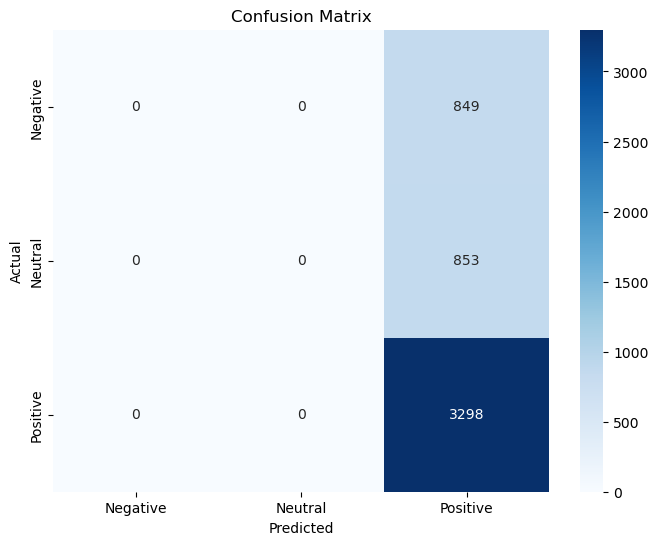

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



✅ F1 Score for Positive = 0.7949
✅ F1 Score for Negative = 0.0000
✅ Accuracy = 0.6596


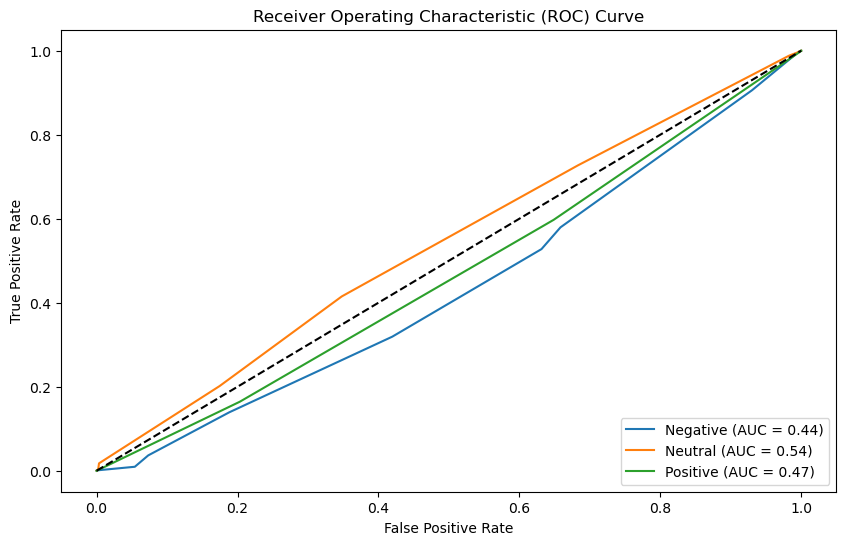

✅ AUC for Negative = 0.4369
✅ AUC for Neutral = 0.5377
✅ AUC for Positive = 0.4668


In [15]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on the test data
y_test_pred = model.predict(X_test_pad)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
report = classification_report(y_test_encoded, y_test_pred_classes, target_names=label_encoder.classes_, output_dict=True)

f1_positive = report['Positive']['f1-score']
f1_negative = report['Negative']['f1-score']
accuracy = report['accuracy']

print(f"\n✅ F1 Score for Positive = {f1_positive:.4f}")
print(f"✅ F1 Score for Negative = {f1_negative:.4f}")
print(f"✅ Accuracy = {accuracy:.4f}")

# 🔍 Compute AUC
y_test_binarized = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

plt.figure(figsize=(10, 6))
for i, label in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")

# Reference line
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Print AUC values
for i, label in enumerate(label_encoder.classes_):
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    print(f"✅ AUC for {label} = {auc_score:.4f}")


# Hyperparameter Tuning

In [16]:
pip install keras-tuner


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: keras-tuner in c:\users\asus\anaconda3\lib\site-packages (1.4.7)




[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.utils.class_weight import compute_class_weight
import time

# Parameters for the model
VOCAB_SIZE = len(tokenizer.word_index) + 1
MAX_SEQ_LENGTH = MAX_SEQUENCE_LENGTH

# Compute Class Weights for Imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weight_dict = dict(enumerate(class_weights))

# Transformer Block (Simplified)
def transformer_block(inputs, hidden_size, num_heads, dropout_rate):
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=hidden_size)(inputs, inputs)
    attention = layers.Dropout(dropout_rate)(attention)
    attention = layers.LayerNormalization(epsilon=1e-6)(inputs + attention)

    # Feed-Forward Network (Simplified)
    ffn = layers.Dense(hidden_size, activation='relu')(attention)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn_out = layers.LayerNormalization(epsilon=1e-6)(attention + ffn)

    return ffn_out

# Create Model
def create_model(hidden_size=128, num_heads=4, dropout_rate=0.3, lr=0.0005):
    inputs = layers.Input(shape=(MAX_SEQ_LENGTH,))
    embedding_layer = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=hidden_size, input_length=MAX_SEQ_LENGTH)(inputs)

    x = embedding_layer
    x = transformer_block(x, hidden_size, num_heads, dropout_rate)

    x = layers.GlobalAveragePooling1D()(x)
    output = layers.Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.01))(x)

    model = models.Model(inputs=inputs, outputs=output)
    
    optimizer = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Hyperparameter Search (Manual Tuning)
dropout_rates = [0.2, 0.3, 0.5]
attention_heads = [2, 4, 8]
learning_rates = [0.0005, 0.001]

best_model = None
best_score = 0

start_time = time.time()

for dr in dropout_rates:
    for ah in attention_heads:
        for lr in learning_rates:
            print(f"Tuning Model: Dropout={dr}, Heads={ah}, LR={lr}")
            model = create_model(hidden_size=128, num_heads=ah, dropout_rate=dr, lr=lr)

            history = model.fit(X_train_pad, y_train_encoded,
                                validation_split=0.2,
                                epochs=10,
                                batch_size=64,
                                class_weight=class_weight_dict,
                                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)])

            val_acc = max(history.history['val_accuracy'])
            if val_acc > best_score:
                best_score = val_acc
                best_model = model

end_time = time.time()

print(f"\nBest Validation Accuracy: {best_score:.4f}")
print(f"Tuning Time: {end_time - start_time:.2f} seconds")

# Train Best Model
history = best_model.fit(X_train_pad, y_train_encoded,
                         epochs=10,
                         batch_size=64,
                         validation_data=(X_test_pad, y_test_encoded))

# Model Summary
best_model.summary()


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Tuning Model: Dropout=0.2, Heads=2, LR=0.0005
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 135ms/step - accuracy: 0.4357 - loss: 1.1508 - val_accuracy: 0.7015 - val_loss: 0.8145
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - accuracy: 0.7269 - loss: 0.8375 - val_accuracy: 0.7435 - val_loss: 0.7173
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.8438 - loss: 0.5177 - val_accuracy: 0.7825 - val_loss: 0.6338
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9167 - loss: 0.3079 - val_accuracy: 0.7368 - val_loss: 0.8240
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.9458 - loss: 0.2046 - val_accuracy: 0.7555 - val_loss: 0.9121
Tuning Model: Dropout=0.2, Heads=2, LR=0.001
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 137ms/step - accuracy: 0.4205 - loss: 1.3499 - val_accuracy: 0.7255 - val_loss: 0.7618
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.7679 - loss: 0.7200 - val_accuracy: 0.7905 - val_loss:

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)    │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_9 (Embedding)       │ (None, 100, 128)          │       9,071,232 │ input_layer_9[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_12       │ (None, 100, 128)          │         263,808 │ embedding_9[0][0],         │
│ (MultiHeadAttention)          │                           │                 │ embedding_9[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_41 (Dropout)          │ (None, 100, 128)          │               0 │ multi_head_attention_12[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_24 (Add)                  │ (None, 100, 128)          │               0 │ embedding_9[0][0],         │
│                               │                           │                 │ dropout_41[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_24        │ (None, 100, 128)          │             256 │ add_24[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_25 (Dense)              │ (None, 100, 128)          │          16,512 │ layer_normalization_24[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_42 (Dropout)          │ (None, 100, 128)          │               0 │ dense_25[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_25 (Add)                  │ (None, 100, 128)          │               0 │ layer_normalization_24[0]… │
│                               │                           │                 │ dropout_42[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_25        │ (None, 100, 128)          │             256 │ add_25[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_9    │ (None, 128)               │               0 │ layer_normalization_25[0]… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_26 (Dense)              │ (None, 3)                 │             387 │ global_average_pooling1d_… │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 28,057,355 (107.03 MB)

 Trainable params: 9,352,451 (35.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,704,904 (71.35 MB)

# Cross Validation

In [18]:
from sklearn.model_selection import KFold
import numpy as np

# Number of folds
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Store results
cv_scores = []
fold_no = 1

# Save the initial weights to reset the model each time
initial_weights = model.get_weights()

for train_idx, val_idx in kf.split(X_train_pad):
    print(f"\nTraining on Fold {fold_no}...")

    # Split data into training and validation sets
    X_train_fold, X_val_fold = X_train_pad[train_idx], X_train_pad[val_idx]
    y_train_fold, y_val_fold = y_train_encoded[train_idx], y_train_encoded[val_idx]

    # Reset model to initial state (avoid recreating it)
    model.set_weights(initial_weights)

    # Train the model
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=5,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        verbose=1
    )

    # Evaluate the model on validation data
    score = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold_no} - Loss: {score[0]:.4f}, Accuracy: {score[1]:.4f}")

    # Store the accuracy score
    cv_scores.append(score[1])
    fold_no += 1

# Print overall cross-validation accuracy
print(f"\nAverage Accuracy across {k} folds: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")



Training on Fold 1...
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 96s 189ms/step - accuracy: 0.9263 - loss: 0.2680 - val_accuracy: 0.8970 - val_loss: 0.3417
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 189ms/step - accuracy: 0.9482 - loss: 0.1809 - val_accuracy: 0.8855 - val_loss: 0.4028
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 188ms/step - accuracy: 0.9659 - loss: 0.1196 - val_accuracy: 0.8695 - val_loss: 0.5213
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 188ms/step - accuracy: 0.9745 - loss: 0.0963 - val_accuracy: 0.8572 - val_loss: 0.6563
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 188ms/step - accuracy: 0.9799 - loss: 0.0750 - val_accuracy: 0.8422 - val_loss: 0.7536
Fold 1 - Loss: 0.7536, Accuracy: 0.8422

Training on Fold 2...
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 188ms/step - accuracy: 0.9094 - loss: 0.2973 - val_accuracy: 0.8960 - val_loss: 0.3458
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 189ms/step - accuracy: 0.9486 - loss: 0.1728 - val_accuracy: 0.8890 - val_loss: 0.3921
Epoc

# Testing Data Check

# Confusion Matrix and Classification Report

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step


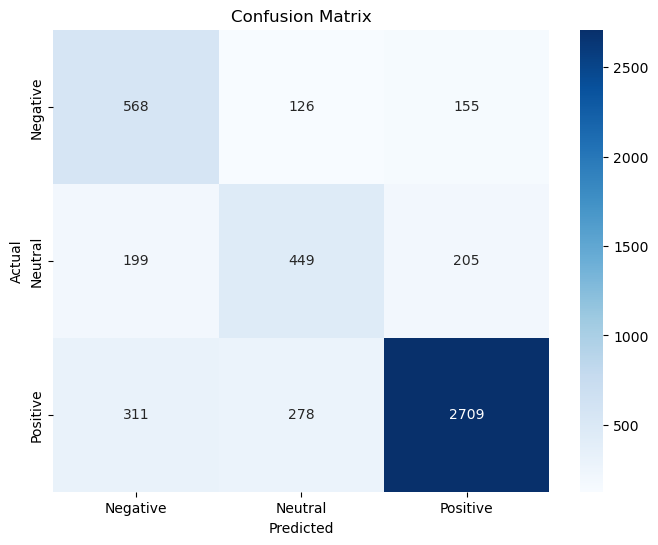


✅ F1 Score for Positive = 0.8510
✅ F1 Score for Negative = 0.5895
✅ Accuracy = 0.7452


In [19]:
# Predict on the test data
y_test_pred = model.predict(X_test_pad)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
report = classification_report(y_test_encoded, y_test_pred_classes, target_names=label_encoder.classes_, output_dict=True)

# Print out F1-Score for Positive and Negative
f1_positive = report['Positive']['f1-score']
f1_negative = report['Negative']['f1-score']
accuracy = report['accuracy']

print(f"\n✅ F1 Score for Positive = {f1_positive:.4f}")
print(f"✅ F1 Score for Negative = {f1_negative:.4f}")
print(f"✅ Accuracy = {accuracy:.4f}")


# AUC - ROC Curve

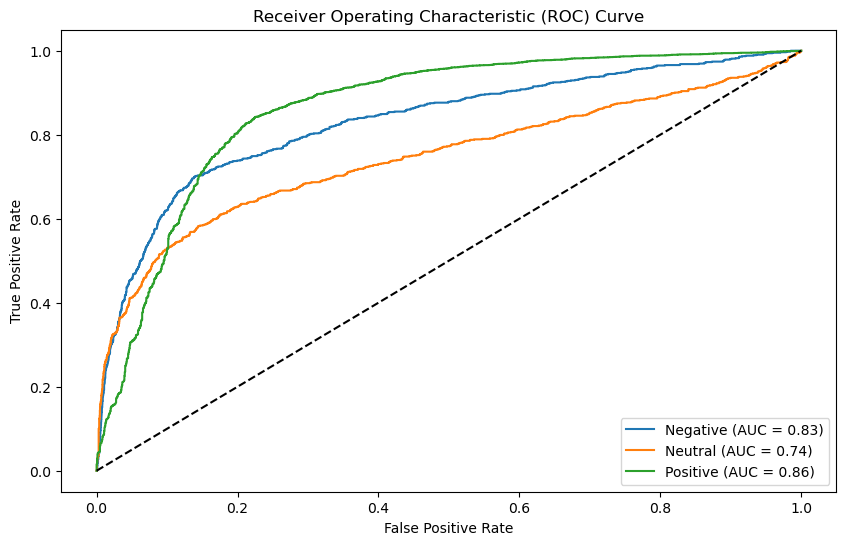

✅ AUC for Negative = 0.8300
✅ AUC for Neutral = 0.7449
✅ AUC for Positive = 0.8612


In [20]:
# Binarize the test labels for ROC AUC calculation
y_test_binarized = tf.keras.utils.to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

# Plot ROC Curve for each class
plt.figure(figsize=(10, 6))
for i, label in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")

# Reference line
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Print AUC values
for i, label in enumerate(label_encoder.classes_):
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_pred[:, i])
    print(f"✅ AUC for {label} = {auc_score:.4f}")


# Access Attention Weights During Prediction

# LIME

In [23]:
!pip install lime



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step


Important Features:
 [('co', -0.42106793147459787), ('capital', -0.18374400170299476), ('t', 0.11365715955339965), ('expected', -0.0876375158300402), ('beyond', -0.0824469376021675), ('Ottawa', -0.0646793332952655), ('convoy', 0.05139174363029133), ('antiVaxxers', 0.041220625293453855), ('as', 0.03235852799616056), ('https', 0.03214429672677919)]


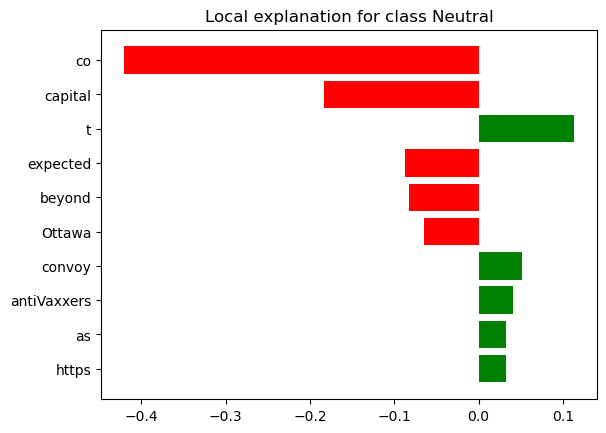

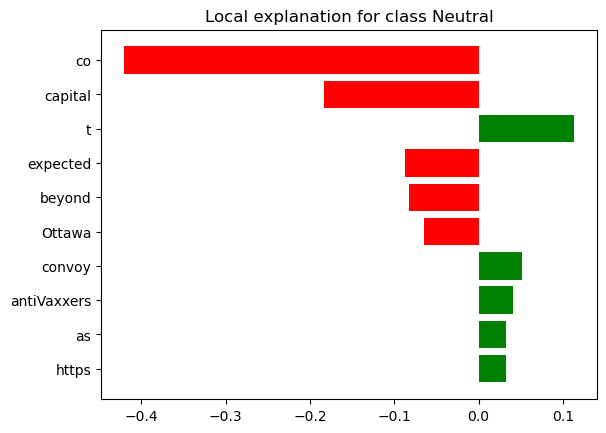

In [25]:
import lime
from lime.lime_text import LimeTextExplainer
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define MAX_SEQ_LEN based on the model input shape
MAX_SEQ_LEN = model.input_shape[1]  # Extract from model input shape

# Initialize the LIME explainer for text classification with class names from the label encoder
explainer = LimeTextExplainer(class_names=label_encoder.classes_)

# Define the prediction function for LIME
def predict_fn(texts):
    # Tokenize the input texts
    seqs = tokenizer.texts_to_sequences(texts)
    # Pad the sequences to the same length as the model input
    padded_seqs = pad_sequences(seqs, maxlen=MAX_SEQ_LEN, padding='post')
    # Predict probabilities for each class using the trained model
    probs = model.predict(padded_seqs)
    return probs

# Choose an instance from the test set to explain (e.g., the first test sample)
text_to_explain = X_test.iloc[0]  # You can modify this to explain other test samples

# Generate the explanation using LIME
explanation = explainer.explain_instance(text_to_explain, predict_fn, num_features=10)

# Visualize the explanation in the notebook
explanation.show_in_notebook()

# Optionally, view the explanation as a list of important features (words)
feature_importance_list = explanation.as_list()
print("Important Features:\n", feature_importance_list)

# Visualize the explanation with a plot (bar chart of feature importance)
explanation.as_pyplot_figure()
